In [1]:
import pandas as pd
import matplotlib.pyplot as plt


# **Comparing Model Results**

In [2]:
files = {
    "AutoReg (walk-forward)": "../data/2_model_autoreg_results.txt",
    "ARMA (one-shot forecast)": "../data/3_model_arma_results.txt",
    "Linear Regression on lags (walk-forward)": "../data/4_model_linreg_results.txt",
}

results = {}
for name, path in files.items():
    with open(path) as f:
        results[name] = float(f.read())

results

{'AutoReg (walk-forward)': 1.2375179866287553,
 'ARMA (one-shot forecast)': 2.5455765939718744,
 'Linear Regression on lags (walk-forward)': 1.237517986628757}

In [3]:
result_df = pd.Series(results, name="test_mae").sort_values()
result_df

AutoReg (walk-forward)                      1.237518
Linear Regression on lags (walk-forward)    1.237518
ARMA (one-shot forecast)                    2.545577
Name: test_mae, dtype: float64

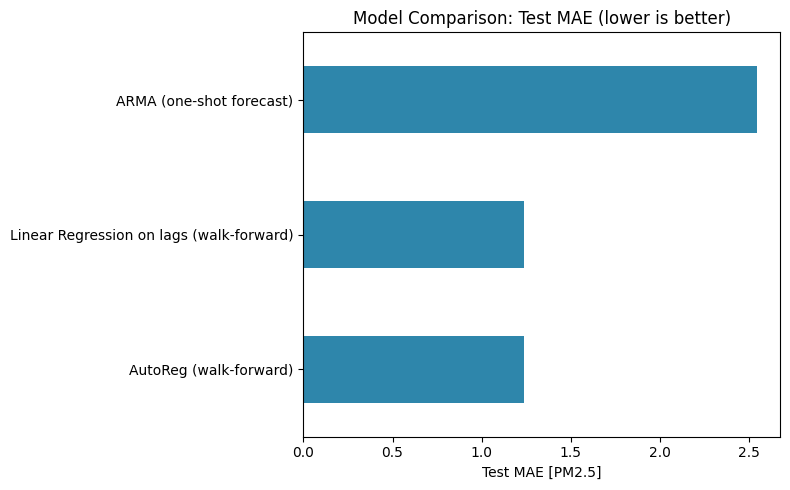

In [4]:
plt.figure(figsize=(8,5))
result_df.plot(kind="barh", color="#2E86AB")
plt.xlabel("Test MAE [PM2.5]")
plt.title("Model Comparison: Test MAE (lower is better)")
plt.tight_layout()
plt.savefig("../images/model_comparison.png", dpi=150)
plt.show()


**Result:** AutoReg and Linear Regression on lag features land at basically the same
MAE -- makes sense, since they're doing the same underlying math (a linear combination of
past values), just through two different implementations. ARMA comes out noticeably worse
here, but that's not really a fair fight -- ARMA was evaluated with a single multi-step
forecast for the whole test window (refitting it at every hour like the other two would
have taken too long), so its errors compound over time instead of getting corrected by
each new observation the way AutoReg and Linear Regression do.

**Takeaway:** for this dataset, a properly walk-forward-validated linear model on lagged
PM2.5 readings is hard to beat with a simple approach. If I wanted to give ARMA a fairer
shot, the next step would be to re-run it with the same walk-forward refitting, accepting
the longer runtime.

Going with **AutoReg** as the final model for this project, since it's purpose-built for
this exact task and had the fastest walk-forward validation of the two lag-based approaches.